# **Colabユーザーへの注意**

# **このファイルに直接書き込まないでください—作業が消えることがあります！**

# **必ず作業前にコピーを作成してください。**

コピーの作り方

1. 左上の「File」をクリック  
> *「File」や「Runtime」などのメニューが見えないときは、右上の“v”マークを押して表示してください。*

2. 「Save a copy in Drive」を選ぶ  

3. コピーしたファイル名を「YOURNAMEs_FileName.ipynb」に変更する  
> 例：名前がOliviaなら → Olivias_FileName.ipynb  


---

* チェックマーク（✅）は保存されません。Chromeのリロードボタンでページを更新すると消えます。<br>  
途中で止めるときは、テキストセルを追加して「SO FAR DONE」など書いておいてください。

---

* Colabでは**30分〜90分ごとに以前の出力結果がリセットされます**。<br>  
そのため、`~~ is not defined`のようなエラーが**すごくよく起こります**。

🔁 `~~ is not defined`エラーが出たらどうする？

1. まず変数名のスペルを確認してください。<br>  
2. スペルが正しいのにまだエラーが出るなら、**そのセルをクリックして選択**してください。<br>  
3. 左上の「Runtime」→「Run before」をクリック。<br>  
→ これで**それまでのすべてのセルが再実行されます**。  
4. 再度、そのセルを実行してください。

もしこれでもエラーが直らなければ、<br>  
前のセルのTODOの答えに基本的なミスがあるかもしれません。<br>  
正しいかどうか確認してください。<br>  
またはChatGPTや他のコーディングアシスタントに助けを求めましょう。

# **Chapter 21: Scaling**

### **Section 1: パラメータ数の推定**

今回のテーマは最適なモデルサイズを決めることです。

もう少し正確にいうと、T4 GPU (6時間) の計算資源に対して、最適な埋め込み次元数を決めることです。

これらにつして考察する前に、まずは埋め込み次元数とパラメータ数の関係を確認しておきましょう。

結論から言うと、中間層の埋め込み次元数が埋め込み次元数の4倍の場合、  
埋め込み次元数 $d_{\text{model}}$ に対する **1つの Transformer ブロックのパラメータ数** は

$$
12d_{\text{model}}^2
$$

で表されます。
ここで、今となっては懐かしい *Tensor Map* を見返しながら進めていきましょう。

[🔗 Tensor Map（Canvaリンク）](https://www.canva.com/design/DAGskS8QP6k/1zs7IklaMrB_LncHn2I8pA/edit)


#### **考慮しないパラメータ**

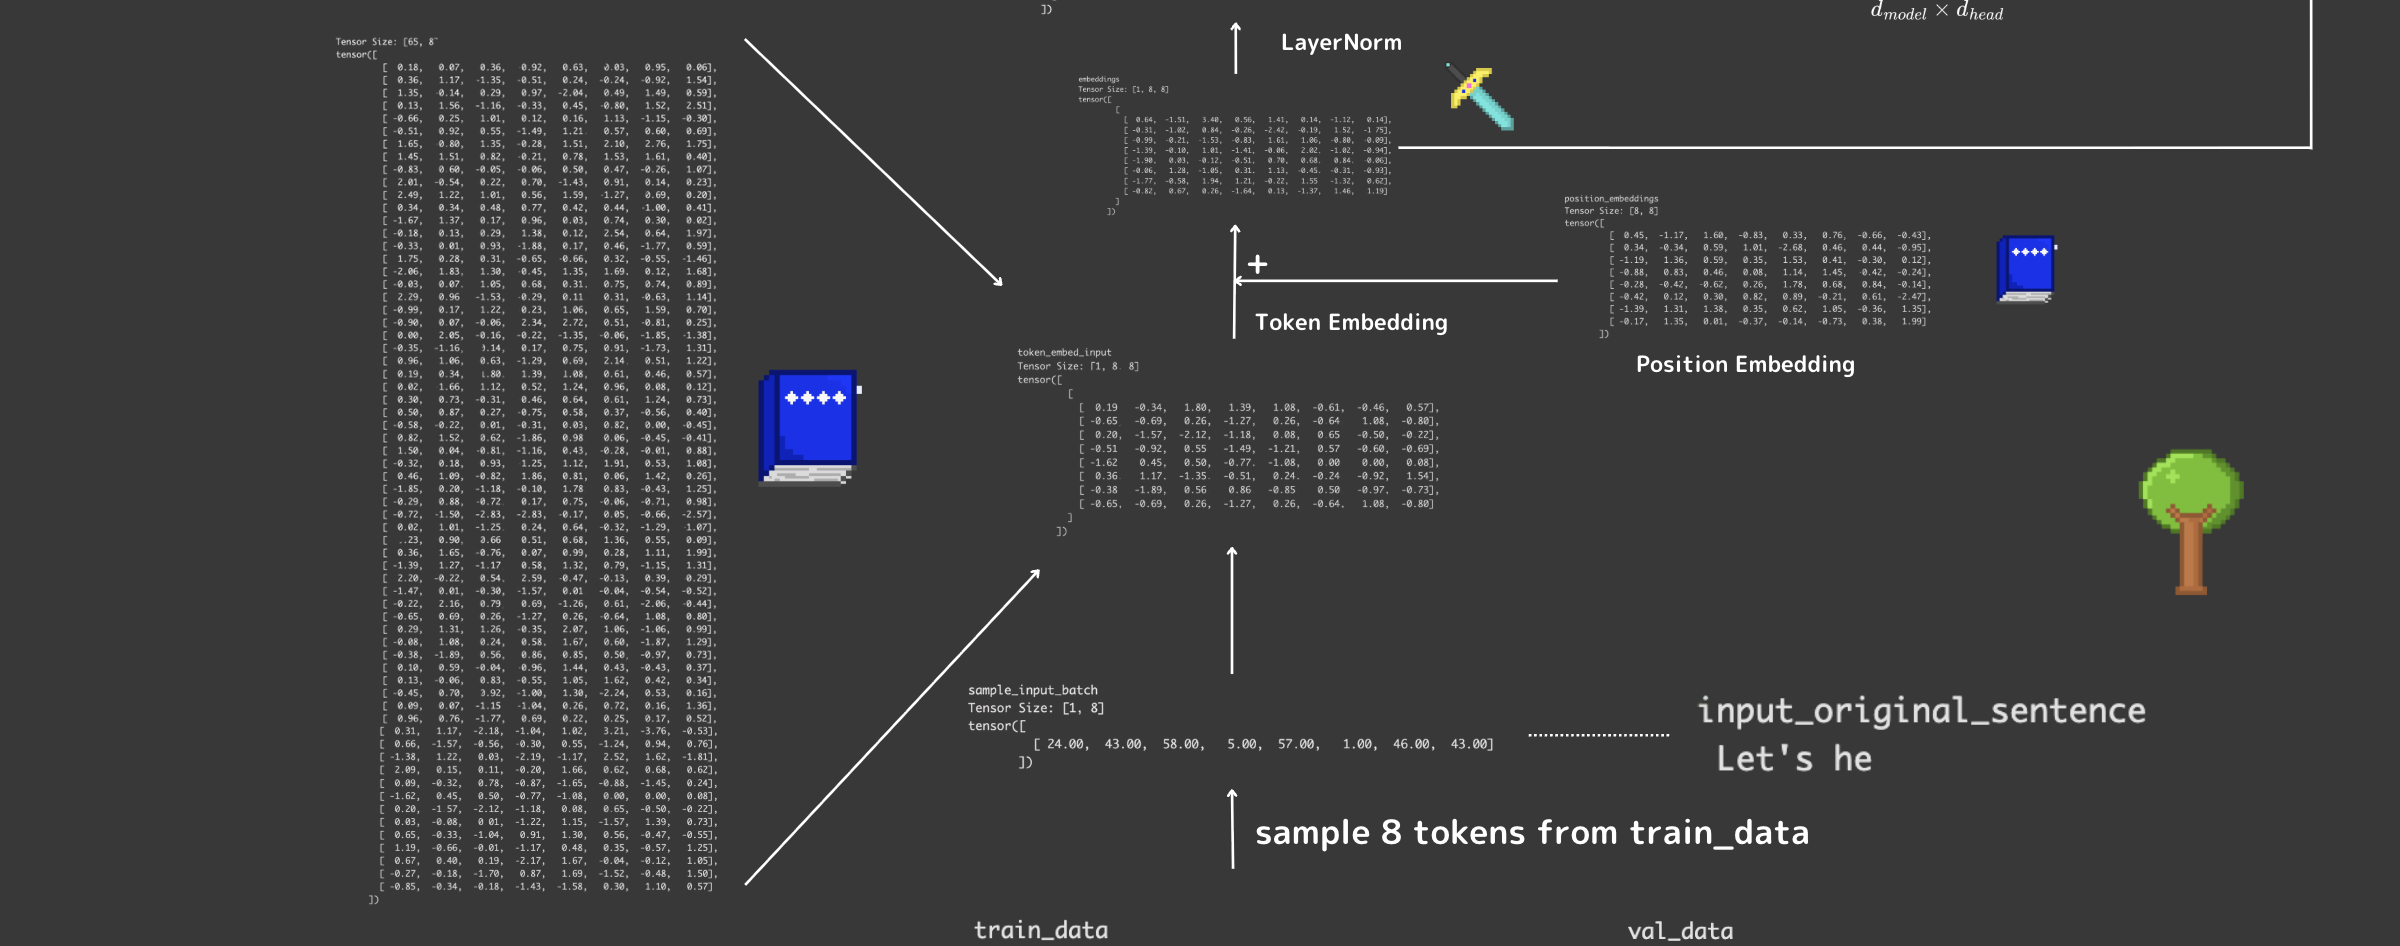

なお、`Token Embedding` と `Position Embedding` の `nn.Embedding` は、パラメータ数としては非常に大きいものの、計算コストの増大には寄与しません。

これは、基本的に「辞書の検索」と同じ処理であり、`nn.Linear` のような行列積演算を伴わないためです。

そのため、言語モデルで「パラメータ数」と言う場合は、通常  
**「非埋め込み層（Non-Embedding Layers）」のパラメータ数** を指します。

また、今回は計算を簡略化するため、`nn.LayerNorm` のパラメータ数は無視します。

`nn.LayerNorm` の学習可能パラメータは以下の2種類です：

- γ ($\gamma$) → 正規化後の値を **スケーリング（伸縮）** する（初期値: 1）  
- β ($\beta$) → 正規化後の値を **シフト（平行移動）** する（初期値: 0）

それぞれの次元数は $d_{\text{model}}$ なので、合計パラメータ数は

$$
2 \times d_{\text{model}}
$$

---

しかし、`nn.Linear` の重み $W$ のパラメータ数は $d_{\text{model}} \times d_{\text{model}}$ のスケールであり、  
LayerNorm の $d_{\text{model}}$ スケールは**桁違いに小さい（微小項）** ため無視します。

同様の理由で、`nn.Linear` の **バイアス項** も $d_{\text{model}}$ スケールであり、無視します。

したがって、以降の計算では  
**`nn.Linear` の重み $W$ パラメータのみを考慮** します。


#### **Key, Query, Value の重み**

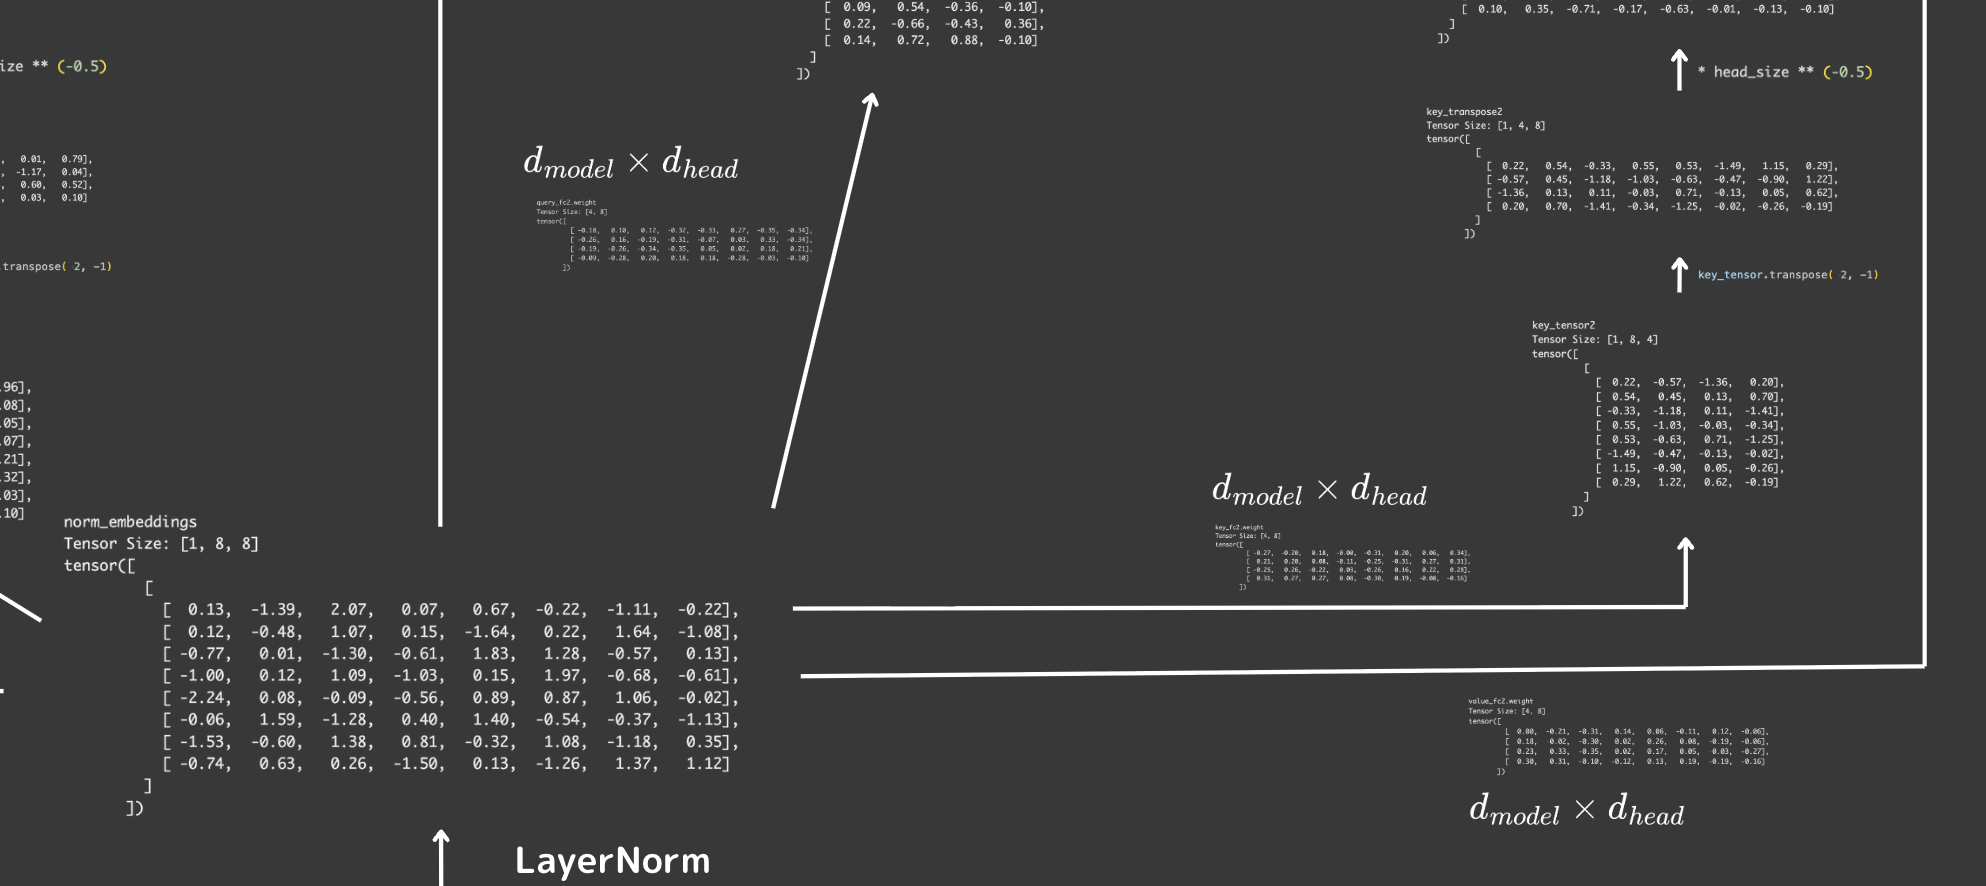

上記の通り、`d_model` から `d_head` への `nn.Linear` が各ヘッドに存在します。

それぞれの重みパラメータ数は、**Key**, **Value**, **Query** ごとに  

$$
d_{\text{model}} \times d_{\text{head}}
$$

したがって、各ヘッドの合計パラメータ数は

$$
d_{\text{model}} \times d_{\text{head}} \times 3
$$

ヘッド数を $ n_{\text{head}} $ とすると、全体の合計は

$$
d_{\text{model}} \times d_{\text{head}} \times 3 \times n_{\text{head}}
$$

ここで $ d_{\text{head}} \times n_{\text{head}} = d_{\text{model}} $ なので、

$$
3d_{\text{model}}^2
$$

に簡略化されます。


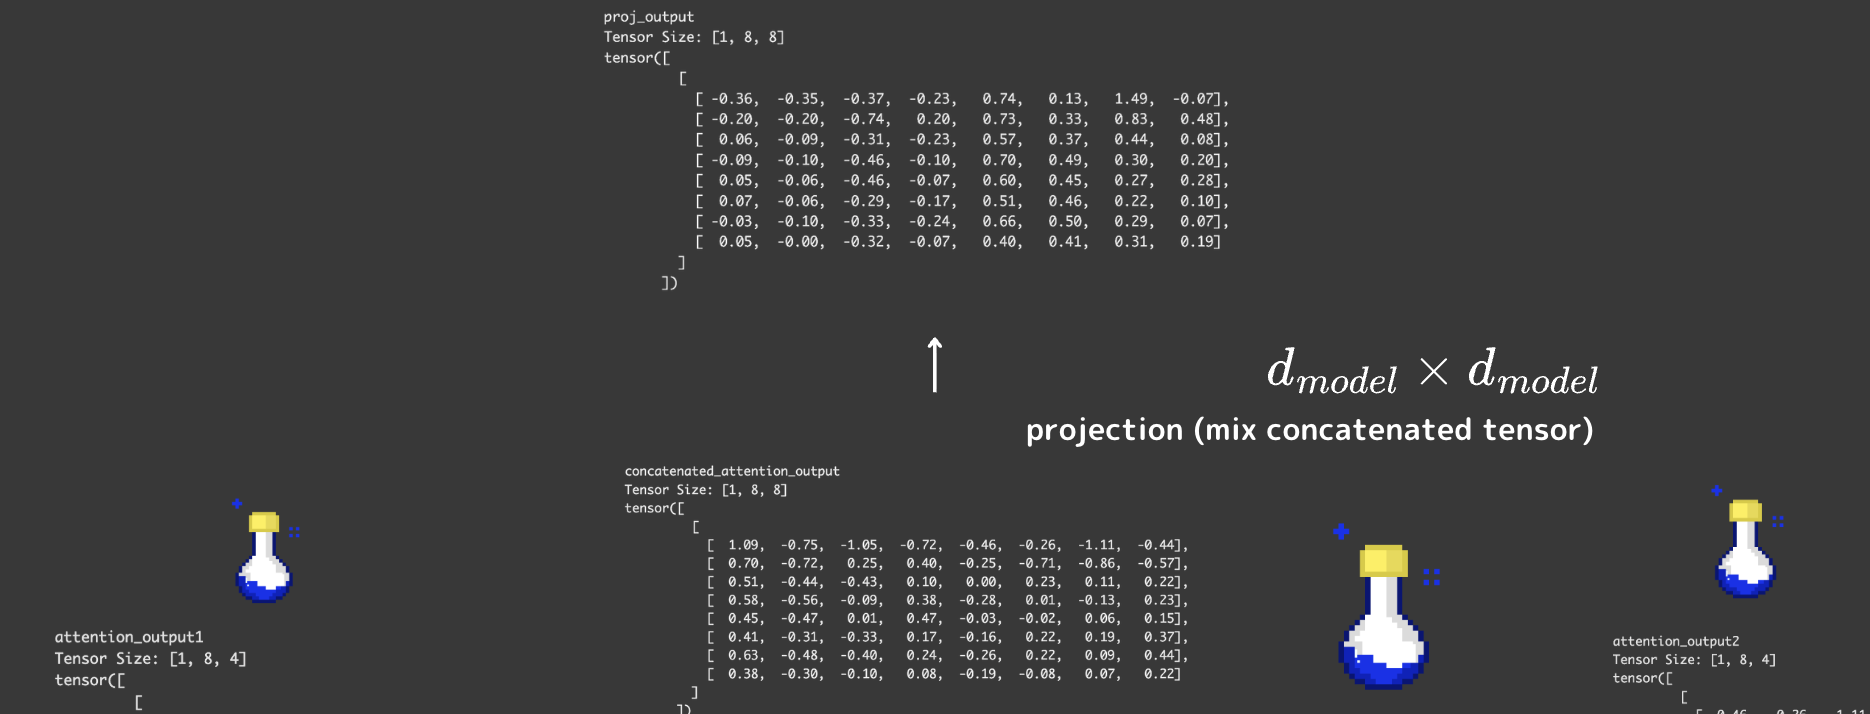

次に、連結（concat）された行列を投影するときの `nn.Linear` 層におけるパラメータ数は

$$
d_{\text{model}} \times d_{\text{model}} = d_{\text{model}}^2
$$

この線形変換は、マルチヘッドアテンションで各ヘッドの出力を結合した後に  
元の次元へ戻すための処理です。


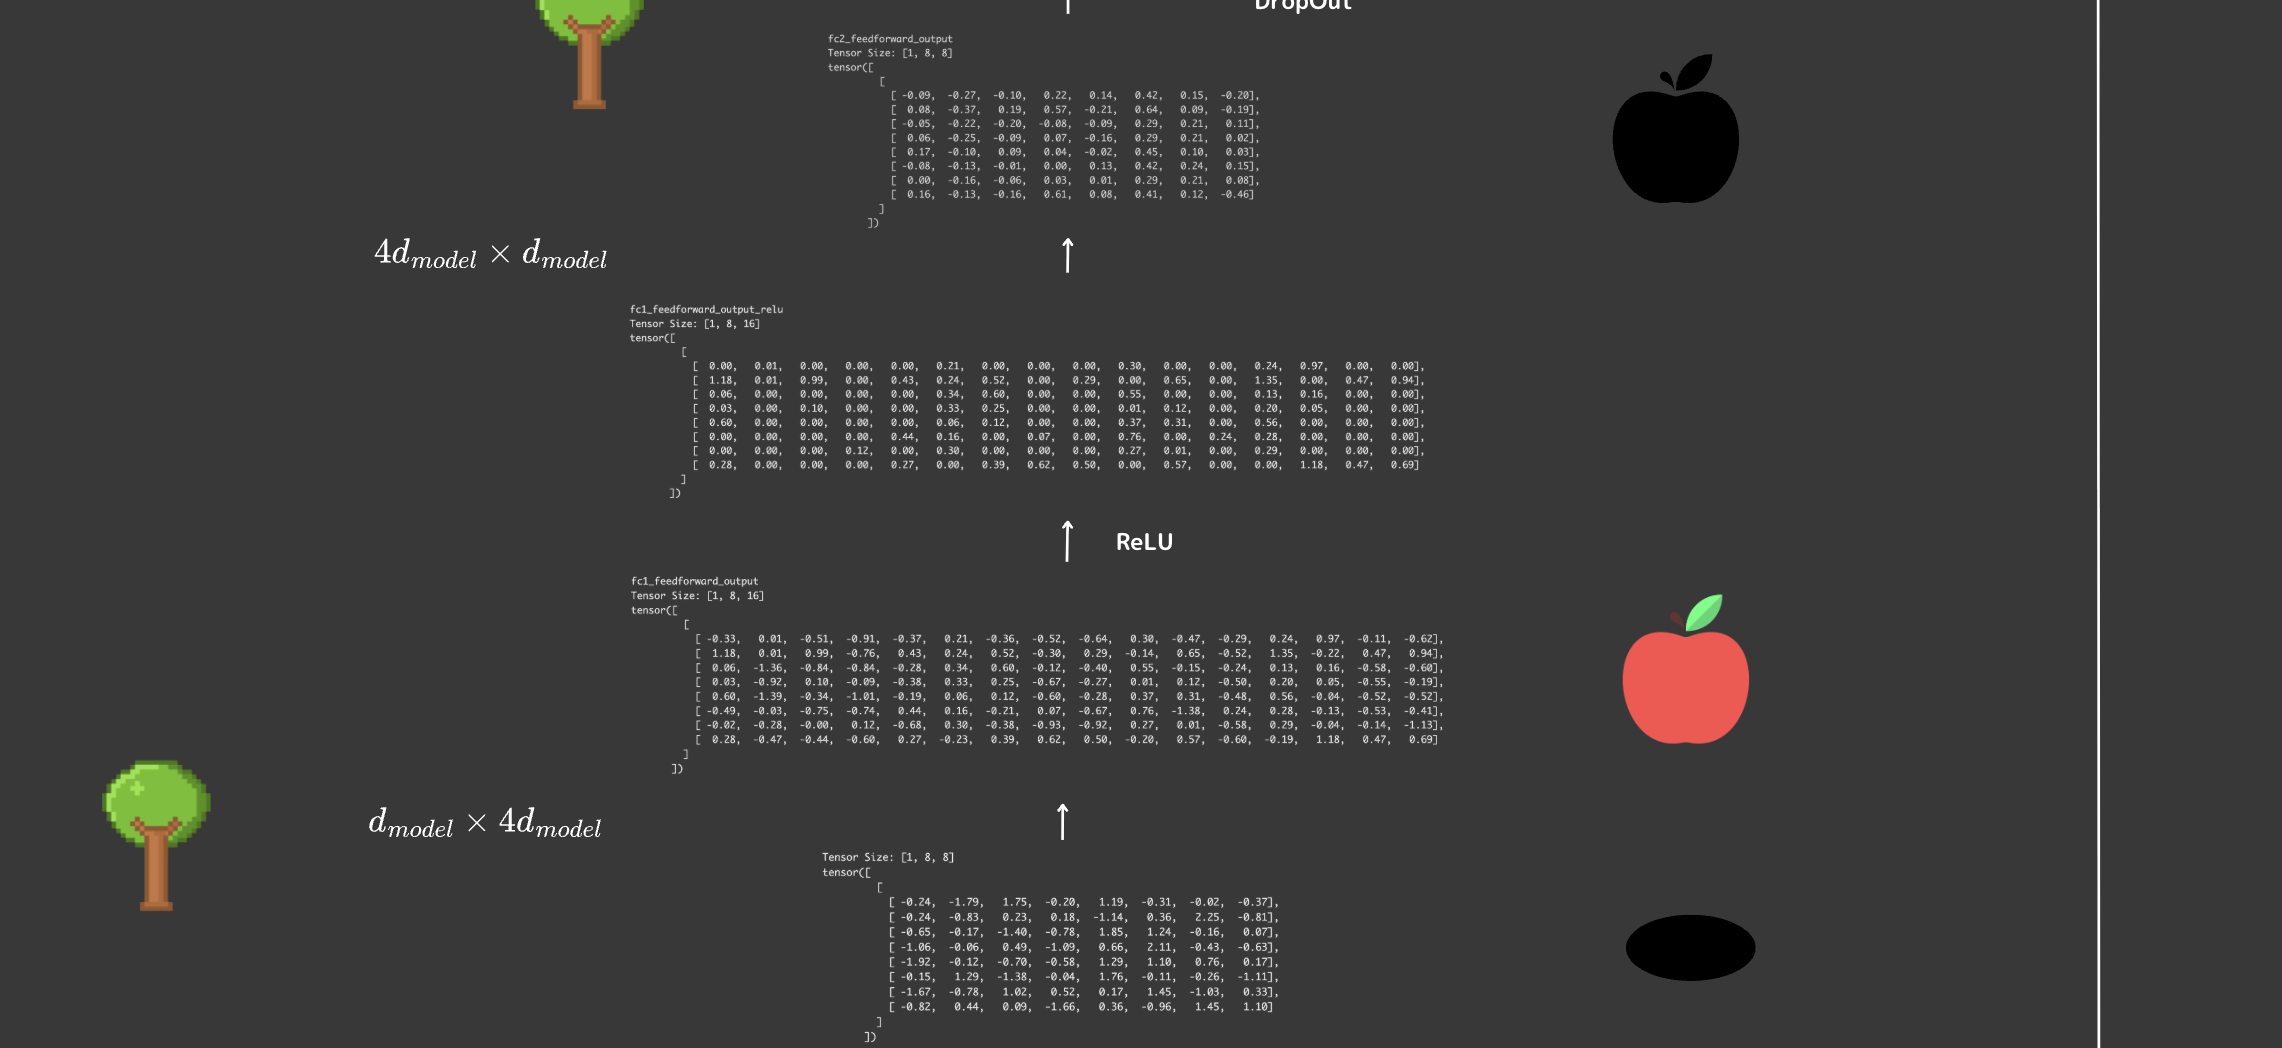

次に、Feed Forward Network 層での中間層の次元数を $4d_{\text{model}}$ とする場合、パラメータ数は

$$
d_{\text{model}} \times 4d_{\text{model}} + 4d_{\text{model}} \times d_{\text{model}} = 8d_{\text{model}}^2
$$

これでわかる通り、FFN層はTransformerブロックの総パラメータ数の2/3を占め、モデルサイズに大きな影響を与えます。

なお、中間層の次元数を $4d_{\text{model}}$ とする必然性はなく、より小さくしても構いません。

ただ、一般的には $3d_{\text{model}}$ から $4d_{\text{model}}$  の範囲で設定されます。


#### 🔹 Transformer Block のパラメータ数

1つの Transformer Block の非埋め込みパラメータ数は

$$
3d_{\text{model}}^2 + d_{\text{model}}^2 + 8d_{\text{model}}^2 = 12d_{\text{model}}^2
$$

よって、ブロック数を  $n_{\text{layer}} $ とすると、全ブロックの合計は

$$
12d_{\text{model}}^2 \times n_{\text{layer}}
$$


#### 🔹 出力層（語彙次元への線形変換）

出力層の `nn.Linear` のパラメータ数は

$$
d_{\text{model}} \times {vocab\_size}
$$

> ※ ただし、**埋め込み層と重み共有**している場合は、  
> この出力層の重みは非埋め込みパラメータに **含めません**。  
>  
> （近年の LLaMA 3.2 などでは重み共有は使われていません）


#### 🔹 総パラメータ数

したがって、重み共有を考慮しない場合、  
Transformer 全体（埋め込み層を除く）のパラメータ数は

$$
12d_{\text{model}}^2 \times n_{\text{layer}} + d_{\text{model}} \times \text{vocab_size}
$$


d_model=512, n_layer=4, vocab_size=50257 の時に、非埋め込み層のパラメータ数の概算を行ってください。

In [ ]:
transformer_blocks_params = 12 * 512 ** 2 * 4 # TODO: 関数を使わず、数値で計算する。
vocab_proj_params = 512 * 50257 # TODO: 関数を使わず、数値で計算する。
total_params = transformer_blocks_params + vocab_proj_params
print("total_params", total_params)
print("transformer_blocks_params", transformer_blocks_params)
print("vocab_proj_params", vocab_proj_params)

語彙次元への線形変換のためのパラメータ数の方が大きいことがわかります。

埋め込み次元数が増えると関係は逆転しますが、語彙サイズは全体のパラメータ数に大きな影響を与えます。

d_model, n_layer, vocab_sizeを入力として、非埋め込み層のパラメータ数の概算を行う関数を完成させてください。

In [ ]:
def non_embed_params(d_model, n_layer, vocab_size):
  result = 12 * d_model **2 * n_layer + d_model * vocab_size # TODO: THINK_BY_YOURSELF
  return result

In [ ]:
print(non_embed_params(128, 4, 50257))

In [ ]:
print(non_embed_params(256, 4, 50257))

In [ ]:
print(non_embed_params(512, 4, 50257))

In [ ]:
print(non_embed_params(1024, 4, 50257))

**Section 1: パラメータ数の推定** <label><input type="checkbox"> Mark as Done</label>

### **Section 2: 最適なモデルサイズ**

今回は、計算資源が限られている場合の最適な埋め込み次元数について考えていきます。

次元数が大きいと、十分な訓練を行うと最終的な検証誤差は小さくなります。

その一方で、1stepあたりの学習にはより多くの時間がかかるため、未学習のまま計算資源を使い切ってしまうかもしれません。


Chapter19では、埋め込み次元数 512 を用いて、T4 GPU上で約6時間の訓練を行いました。  
さらに、埋め込み次元を 128, 256, および 1024 に設定した場合の学習ログも[リンク](https://huggingface.co/datasets/HayatoHongo/GPTtrainlogs)に用意しています。

今回は埋め込み次元数 128, 256, 512, 1024 のうち、ColabのT4 GPU 6時間の計算資源で最も効率的な1つを選びます。

なお、Colabの無料枠では、最長でおよそ12時間までの実行が可能です。  
ただし、たとえば夜9時に開始して翌朝9時に終了するような長時間実行を行うと、  
翌日の学校や仕事へパソコンを持ち運ぶ際に不便が生じる場合があります。  
そのため、夜間実行を考えても6時間程度が現実的な限界だと思います。


---

学習率は、各設定ごとにいくつかの候補を試し、  
最初の 1,000 step において検証誤差が最も小さかったものを最適な学習率として採用しました。


| 埋め込み次元数 | 最適学習率 | 総ステップ数 | 訓練時間（目安） |
|----------------|-------------|---------------|------------------|
| 128            | 4e-3        | 100,000       | 約5.7時間        |
| 256            | 2e-3        | 60,000        | 約5.7時間        |
| 512            | 1e-3        | 30,000        | 約6.2時間        |
| 1024           | 5e-4        | 11,000        | 約5.9時間        |


訓練時間には多少のばらつきがありますが、  
いずれの設定でもおおむね6時間前後で完了しています。





データセットのダウンロード

In [ ]:
!wget https://huggingface.co/datasets/HayatoHongo/GPTtrainlogs/resolve/main/dim128_4e-3_training_logs.csv
!wget https://huggingface.co/datasets/HayatoHongo/GPTtrainlogs/resolve/main/dim256_2e-3_training_logs.csv
!wget https://huggingface.co/datasets/HayatoHongo/GPTtrainlogs/resolve/main/dim512_1e-3_training_logs.csv
!wget https://huggingface.co/datasets/HayatoHongo/GPTtrainlogs/resolve/main/dim1024_5e-4_training_logs.csv

ダウンロードしたcsvファイルを読み込みます。

In [ ]:
import pandas as pd
df128 = pd.read_csv('/content/dim128_4e-3_training_logs.csv')
df256 = pd.read_csv('/content/dim256_2e-3_training_logs.csv')
df512 = pd.read_csv('/content/dim512_1e-3_training_logs.csv')
df1024 = pd.read_csv('/content/dim1024_5e-4_training_logs.csv')

In [ ]:
df128

In [ ]:
df256

In [ ]:
df512

In [ ]:
df1024

In [ ]:
import matplotlib.pyplot as plt

plt.plot(df128["total_train_time"], df128["val_loss"], label="128")
plt.plot(df256["total_train_time"], df256["val_loss"], label="256")
plt.plot(df512["total_train_time"], df512["val_loss"], label="512")
plt.plot(df1024["total_train_time"], df1024["val_loss"], label="1024")

plt.xlabel("total_train_time")
plt.ylabel("val_loss")
plt.legend()
plt.grid(True)
plt.show()

学習ログの結果から、`total_train_time` に応じて最適な埋め込み次元数を選ぶことができます。

| 条件 (`total_train_time`) | 推奨される埋め込み次元数 | 非埋め込みパラメータ数 |
|---------------------------|----------------------------|--------------------------|
| < 3,500                   | 128                        | 約 7M                    |
| 3,500 ～ 15,000           | 256                        | 約 16M                   |
| > 15,000                  | 512                        | 約 38M                   |

計算資源が多くなる（`total_train_time` が長くなる）ほど、  
大きなモデル（埋め込み次元が大きい方）が有利であることがわかります。

単純に「大きいモデルほど良い」というわけではなく、  
利用可能な計算資源に合わせて最適なモデルサイズを選ぶことが重要です。  

ここで終わってしまうと少し物足りないので、  
次はこの傾向をもう少し詳しく見ていきましょう。


図を対数スケールで見てみます。

```python
plt.xscale("log")
```

上記を加えることで、横軸を対数スケールで確認できます。

In [ ]:
plt.plot(df128["total_train_time"], df128["val_loss"], label="128")
plt.plot(df256["total_train_time"], df256["val_loss"], label="256")
plt.plot(df512["total_train_time"], df512["val_loss"], label="512")
plt.plot(df1024["total_train_time"], df1024["val_loss"], label="1024")

plt.xscale("log") # TODO: Type plt.xscale("log")
plt.xlabel("total_train_time")
plt.ylabel("val_loss")
plt.legend()
plt.grid(True)
plt.show()

なお、横軸のスケールは以下のように読みます。

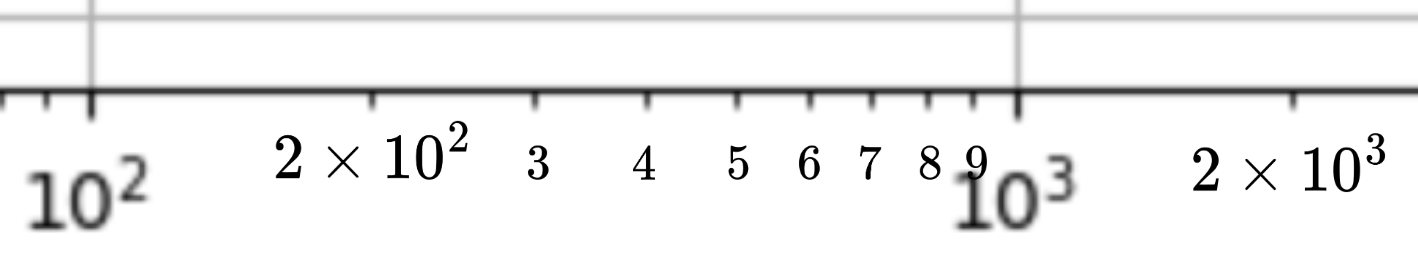

#### 「😳？！」

かかなりきれいな直線になっていることがわかります。

計算資源（`total_train_time`）が増えるにつれて、  
モデルの性能（検証誤差）は一定のスケーリング則に従って改善していく傾向があります。  

これは一般に「スケーリング法則」と呼ばれ、計算量と性能の関係を定量的に示すものです。

また、埋め込み次元数が大きい（＝モデルサイズが大きい）ほど、  
その改善の度合いが急になる傾向が見られます。

---

...緑色の直線(512)と赤色(1024)の直線が交差する点を思い浮かべる方、いますよね？

---

`total_train_time` は 2 * 10^4 付近で終わっていますが、 10^5 のときには、  
埋め込み次元数を 1024 にした方が検証誤差がより小さくなることが予想できます。  
検証誤差はおそらく、4 を下回るあたりになるでしょう。

これが示しているのは、  モデルサイズや計算規模が、  
ある程度「予測可能」になりつつあるということです。  
言語モデルの開発が、偶然や試行錯誤の産物ではなく、  
計画的に設計・生産できる段階に近づいているのです。


**Section 2: 最適なモデルサイズ** <label><input type="checkbox"> Mark as Done</label>

### **Section 3: Chinchilla（読むだけ）**

これをより大規模な実験で検証したのが DeepMind社 の Chinchilla です（Hoffmann et al., 2022）。

図の出典：Hoffmann et al. (2022, Figure 2)

論文の出典（APAスタイル）

Hoffmann, J., Borgeaud, S., Mensch, A., Buchatskaya, E., Cai, T., Rutherford, E., ... & Irving, G. (2022). *Training compute-optimal large language models.* arXiv preprint arXiv:2203.15556. [https://arxiv.org/abs/2203.15556](https://arxiv.org/abs/2203.15556)

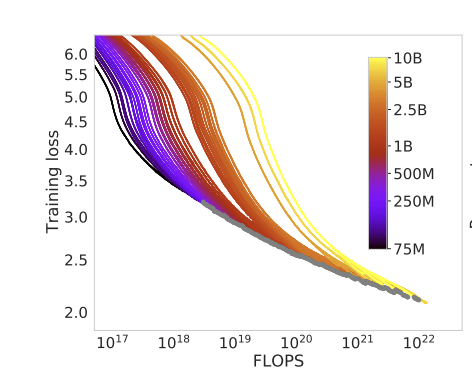

Figure 2 を見ると、完全な直線というよりは、わずかに曲率をもつ滑らかな関係が確認できます。  
興味深いのは、モデルサイズ（パラメータ数）が異なっても、この関係の形状がほとんど変化しない点です。

また、計算資源が増加するにつれて、より大きなモデルを用いた方が性能（低い訓練誤差）を達成できる傾向も明確に示されています。


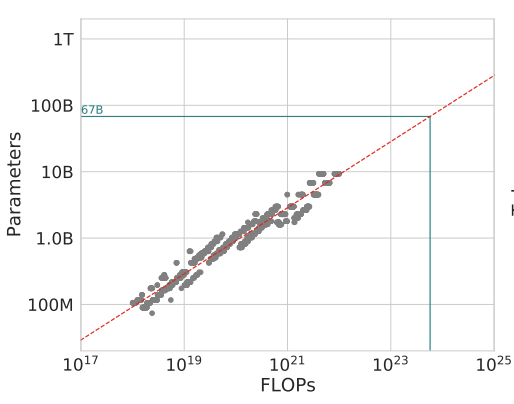

同じ Figure 2 には、上図の通り、計算資源に対して最適なパラメータ数を示すプロットも含まれています。  
ここでも明確なスケーリング則が観察されます。

具体的には、10^21 FLOPs における最適なパラメータ数はおよそ2.0Bであり、

10^19 FLOPs における最適なパラメータ数である200Mの約 10 倍となっています。  

すなわち、**計算資源（FLOPs）を 100 倍に増やすと、最適なモデルパラメータ数は約 10 倍に増加する**、  
これがいわゆる *Chinchilla Scaling Law*（チンチラ則）です。

（出典：Hoffmann et al., 2022, *Training Compute-Optimal Large Language Models*, Figure 2）

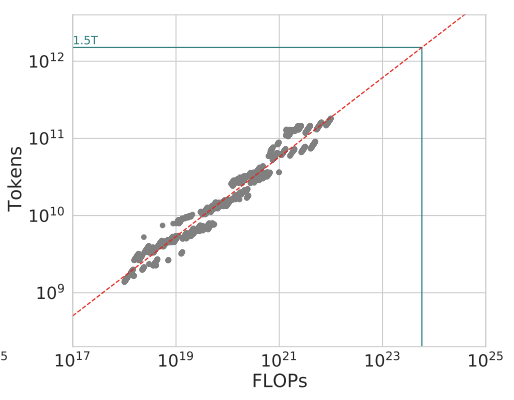

残りの 10 倍は、学習に用いるトークン数（データ量）の増加に使われます。  
つまり、計算資源が 100 倍になれば、モデルサイズを 10 倍、学習データ量も 10 倍にする――  
これが DeepMind の *Chinchilla Scaling Law*（チンチラ則）の考え方です（Hoffmann et al., 2022）。


一方、OpenAI の先駆的研究 *Scaling Laws for Neural Language Models*（Kaplan et al., 2020）では、  
計算資源が100倍に増えるとモデルサイズをより大きく（およそ 25 倍）、データ量をやや増やす（約 4 倍）方が  
最適であると報告されています。

主張が異なりますね。どちらも理論的な導出ではなく実験的な経験則です。

今回の場合、どちらの方がより有用なのでしょうか？確認してみましょう。

**参考文献（APAスタイル）**  
- Kaplan, J., McCandlish, S., Henighan, T., Brown, T. B., Chess, B., Child, R., … & Amodei, D. (2020). *Scaling laws for neural language models.* arXiv preprint arXiv:2001.08361.  
- Hoffmann, J., Borgeaud, S., Mensch, A., Buchatskaya, E., Cai, T., Rutherford, E., … & Rae, J. W. (2022). *Training compute-optimal large language models.* arXiv preprint arXiv:2203.15556.


#### **今回の実験結果を用いた簡易的な検証**

まず、次の表を思い出してください。

※ 3,500 や 15,000 はおおよその目安です。本来は各モデルの損失曲線を補間して交点を求めるべきですが、ここでは簡易的な推定値を用いています。  
このような目分量の設定は、結果を大きく左右する可能性がある点に注意してください。

| 条件 (`total_train_time`) | 推奨される埋め込み次元数 | 非埋め込みパラメータ数 |
|---------------------------|----------------------------|--------------------------|
| < 3,500                   | 128                        | 約 7M                    |
| 3,500 ～ 15,000           | 256                        | 約 16M                   |
| > 15,000                  | 512                        | 約 38M                   |

`total_train_time` が 3,500 のとき、最適な埋め込み次元は 128 から 256 に変わり、非埋め込みパラメータ数は約 16M。  
`total_train_time` が 15,000 のときは、最適な埋め込み次元は 256 から512 に変わり、非埋め込みパラメータ数は約 38M です。

計算予算（`total_train_time` の比）は  
15,000 / 3,500 ≒ **4.3 倍**。

モデルサイズ（非埋め込みパラメータ数）は  
38M / 16M ≒ **2.4 倍**。

また、`total_train_time = 3,500` のとき、256 次元モデルの `total_seen_tokens` は約 83M トークン。  
`total_train_time = 15,000` のとき、512 次元モデルの `total_seen_tokens` は約 166M トークンです。  
（補足として、`total_train_time = 15,000` のとき、256 次元モデルは約 358M トークンを処理しています。）

したがって、トークン数の比は  
166 / 83 ≒ **2.0 倍** となります。

学習時の計算コスト（FLOPs）の増加率はおおむね  
**「非埋め込みパラメータ数の増加率 × 学習トークン数の増加率」に比例** します。  
したがって、  
2.4（非埋め込みパラメータの増加率） × 2.0（トークン数の増加率） ≒ **4.8 倍**  
となるはずですが、実測の `total_train_time` 比（4.3 倍）とはわずかに異なります。

この差は、埋め込み層やバイアス項などの固定的な計算コストを無視している点が主な要因と考えられます。  

したがって、この程度のずれは実測上の誤差として問題ありません。

まとめると、今回の小規模実験では、  
計算予算が約 4.3 倍に増えたとき、最適なモデルサイズ（非埋め込みパラメータ数）は約 2.4 倍、  
学習トークン数は約 2.0 倍に増加しました。

これは、**計算予算の大半をモデルサイズ拡大に割り当てる従来の OpenAI Scaling Law よりも、  
モデルサイズとデータ量をおおよそ同じ比率で増やす Chinchilla Scaling Law に近い挙動** と言えます。

実際、2022 年以降の大規模モデル開発においても、  
この *Chinchilla Scaling Law* に基づいた設計指針が主流となっています。

また、Chinchilla の実験結果から、**最適なモデルサイズと学習データ量の比率はおよそ 1:20**  
（1 パラメータあたり約 20 トークン）であるとされています。

例えば、70B パラメータのモデルには約 1.4T トークン（1.4 兆トークン）のデータが適切という具合です。

ただし、この比率はその後の研究や新しい手法の登場、
たとえば RoPE（Rotary Positional Embedding）によって 変化している可能性があります。

**Section 3: Chinchilla（読むだけ）** <label><input type="checkbox"> Mark as Done</label>

### **Section 4: サンプル効率**

横軸を`"total_seen_tokens"`、縦軸を`"val_loss"`としてグラフにプロットします。

In [ ]:
plt.plot(df128["total_seen_tokens"], df128["val_loss"], label="128") # TODO: THINK_BY_YOURSELF
plt.plot(df256["total_seen_tokens"], df256["val_loss"], label="256")  # TODO: THINK_BY_YOURSELF
plt.plot(df512["total_seen_tokens"], df512["val_loss"], label="512")  # TODO: THINK_BY_YOURSELF
plt.plot(df1024["total_seen_tokens"], df1024["val_loss"], label="1024")  # TODO: THINK_BY_YOURSELF

plt.xlabel("total_seen_tokens")
plt.ylabel("val_loss")
plt.legend()
plt.grid(True)
plt.show()

最後に、モデルサイズごとのサンプル効率の違いを確認します。

図を見ると、約 10^7 トークンで学習した埋め込み次元 1024 のモデルは、  
10^8 トークン以上を学習した埋め込み次元 128 のモデルよりも  
検証誤差が小さいことがわかります。

このように、**大きなモデルほどサンプル効率が高く、  
より少ないデータで高い性能を発揮できる傾向**があります。  
（※これは学習率や最適化条件が適切に調整されている場合に成立します。）

一方で、小さなモデルはサンプル効率が低く、  
同じ性能を得るにはより多くのデータが必要です。  
ただし、計算コストが小さいため、限られた計算資源でも  
長時間・大規模なデータ学習が可能という利点があります。

しかし、モデルサイズが小さすぎる場合には、  
表現力の限界により検証誤差が頭打ちとなる、  
いわゆる **loss plateau（損失の停滞）** が発生します。  
埋め込み次元 128 のモデルのように、  
どれだけ新しいデータで訓練しても性能が改善しないケースがこれに該当します。

---

大きなモデルの課題は、主に **計算資源とコストの確保** にあります。  
さらに、大規模分散学習を支えるための **インフラ構築やエンジニアリング体制** も欠かせません。

一方、小さなモデルは、たとえ数兆トークン（T tokens）規模の学習であっても  
必要な計算量は大規模モデルに比べて桁違いに小さくなります。  
しかし前述の通り、loss plateau により性能向上が頭打ちになる問題があります。  
このため、**アーキテクチャの改良**が極めて重要です。

---

近年では、非Transformer系アーキテクチャとして  
**LFM2 モデル** や **Mamba モデル** が登場しています。

LFM2（Liquid Feedforward Model）は、状態空間モデル（State Space Model, SSM）系の手法をベースにしたモデルで、  
同規模の Transformer モデルと比較して高速かつ高効率に学習できることが報告されています。  
特定のベンチマークでは、同等またはそれ以上の性能を示す例もあります。  
参照: [LiquidAI / LFM2-350M](https://huggingface.co/LiquidAI/LFM2-350M)

[実際に使ってみる🤖](https://playground.liquid.ai/chat?model=cmewfn9y2000008lbey9u2hf7)

---

こうした新しいアーキテクチャは、  
**サンプル効率と計算効率の両立**を目指す次世代モデルとして注目されています。  
今後は、Transformer に代わる基盤モデルとして、  
これらの系統の発展が期待されています。

しかし依然として、Transformer系モデルは圧倒的に大きな勢力です。

このChapter以降も、引き続きTransformer系モデルをさらに極めていきます。

**Section 4: サンプル効率** <label><input type="checkbox"> Mark as Done</label>

**Chapter 21: Scaling** <label><input type="checkbox"> Mark as Done</label>